<a href="https://colab.research.google.com/github/ZeyadArafat/phase-3/blob/main/GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import zipfile
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [2]:
!pip install kaggle

In [3]:
!mkdir -p ~/.kaggle
!echo "KGAT_7db59505008cf02968e67cf12e8669aa" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [4]:
def find_folder(base):
    for root, dirs, files in os.walk(base):
        imgs = [f for f in files if f.endswith((".jpg", ".png"))]
        if len(imgs) > 100:
            print("Using folder:", root)
            return root

DATA_PATH = find_folder("/content/bdd100k")

In [5]:
!kaggle datasets download -d solesensei/solesensei_bdd100k

Dataset URL: https://www.kaggle.com/datasets/solesensei/solesensei_bdd100k
License(s): other
100% 7.61G/7.61G [00:56<00:00, 144MB/s]



In [6]:
import zipfile

with zipfile.ZipFile("solesensei_bdd100k.zip", 'r') as zip_ref:
    zip_ref.extractall("bdd100k")

In [7]:
import os
import shutil

src = "/content/bdd100k/bdd100k/bdd100k/images/100k/train"
dst = "bdd_subset"

os.makedirs(dst, exist_ok=True)

files = [
    f for f in os.listdir(src)
    if f.endswith((".jpg", ".png"))
]

files = files[:2000]

for f in files:
    shutil.copy(os.path.join(src, f), dst)

print("Done ✔️")

Done ✔️


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

import numpy as np
import os
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
SEQ_LEN = 5
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 10

In [10]:
DATA_PATH = "bdd_subset"

In [11]:
class SequenceDataset(Dataset):
    def __init__(self, path, seq_len=5):
        self.path = path
        self.seq_len = seq_len

        self.images = sorted([
            f for f in os.listdir(path)
            if f.endswith((".jpg", ".png"))
        ])

        print("Total images:", len(self.images))

    def __len__(self):
        return len(self.images) - self.seq_len

    def __getitem__(self, idx):
        sequence = []

        for i in range(self.seq_len):
            img_path = os.path.join(self.path, self.images[idx + i])

            img = Image.open(img_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))

            img = np.array(img) / 255.0
            img = torch.FloatTensor(img).permute(2, 0, 1)

            sequence.append(img)

        sequence = torch.stack(sequence)
        label = torch.tensor(np.random.randint(0, 10))

        return sequence, label

In [12]:
dataset = SequenceDataset(DATA_PATH, SEQ_LEN)

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Dataset size:", len(dataset))

Total images: 1156
Dataset size: 1151


In [13]:
sample_seq, _ = dataset[0]
print("Single sequence shape:", sample_seq.shape)

for seq, _ in train_loader:
    print("Batch shape:", seq.shape)
    break

Single sequence shape: torch.Size([5, 3, 128, 128])
Batch shape: torch.Size([16, 5, 3, 128, 128])


In [14]:
resnet = models.resnet18(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(device)

for param in resnet.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


In [15]:
class CNN_GRU(nn.Module):
    def __init__(self, hidden_size=128, num_classes=10):
        super().__init__()

        self.gru = nn.GRU(512, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch, seq, c, h, w = x.shape

        features = []

        for t in range(seq):
            with torch.no_grad():
                f = resnet(x[:, t])
                f = f.view(batch, -1)
            features.append(f)

        features = torch.stack(features, dim=1)

        out, _ = self.gru(features)
        out = out[:, -1, :]

        return self.fc(out)

In [16]:
model = CNN_GRU().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
EPOCHS = 3
losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader)

    for sequences, labels in loop:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(sequences)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 72/72 [01:16<00:00,  1.06s/it, loss=2.31]


Epoch 1 Loss: 2.3469


Epoch 2: 100%|██████████| 72/72 [01:13<00:00,  1.02s/it, loss=2.41]


Epoch 2 Loss: 2.3233


Epoch 3: 100%|██████████| 72/72 [01:13<00:00,  1.03s/it, loss=2.28]

Epoch 3 Loss: 2.3185


In [18]:
from sklearn.metrics import accuracy_score

accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []

    for sequences, labels in train_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    accuracies.append(acc)

    print(f"Epoch {epoch+1} Acc: {acc:.4f}")

Epoch 1 Acc: 0.0869
Epoch 2 Acc: 0.0999
Epoch 3 Acc: 0.0938


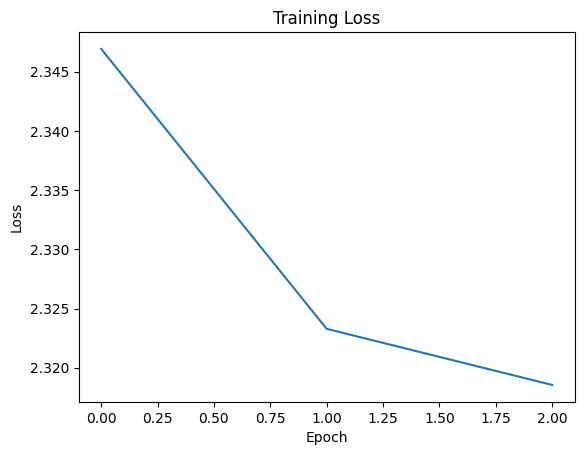

In [20]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

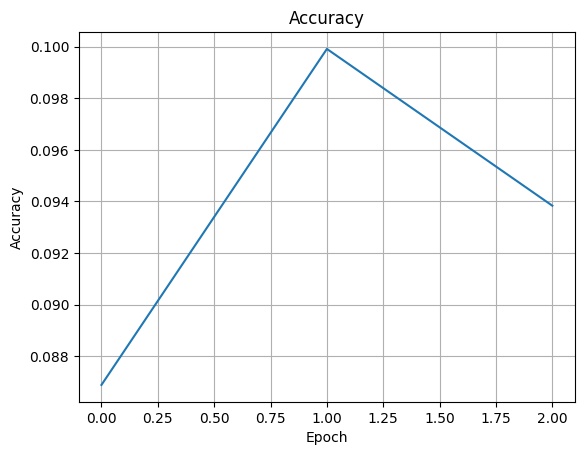

In [21]:
plt.plot(accuracies)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

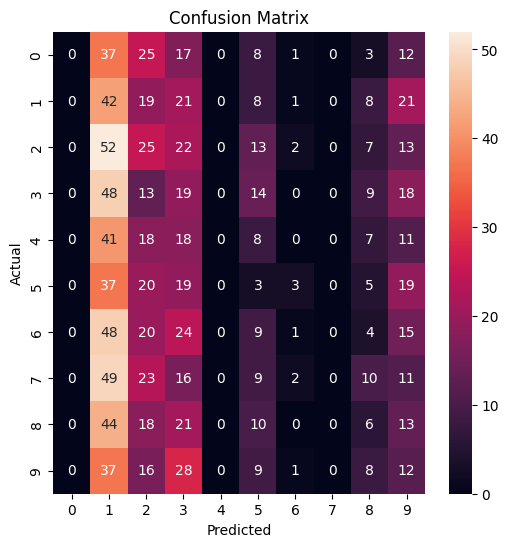

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()